IRMAS dataset is used in this pipeline.
https://www.upf.edu/web/mtg/irmas

Bosch, J. J., Janer, J., Fuhrmann, F., & Herrera, P. “A Comparison of Sound Segregation Techniques for Predominant Instrument Recognition in Musical Audio Signals”, in Proc. ISMIR (pp. 559-564), 2012

In [1]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split

# --- 1. Configuration ---
DATA_DIR = "/home/samuel/Programming/ML/datasets/IRMAS/IRMAS-TrainingData"
TEST_DIR = "/home/samuel/Programming/ML/datasets/IRMAS/IRMAS-TestingData-Part1/Part1"
BATCH_SIZE = 32
IMG_SHAPE = (128, 130, 1)

instrument_list = ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
label_map = {inst: i for i, inst in enumerate(instrument_list)}
NUM_CLASSES = len(instrument_list)

# --- 2. File Discovery ---
file_paths = []
labels = []

for root, dirs, files in os.walk(DATA_DIR):
    folder_name = os.path.basename(root)
    if folder_name in label_map:
        current_label = label_map[folder_name]
        for file in files:
            if file.endswith(".wav"):
                file_paths.append(os.path.join(root, file))
                labels.append(current_label)

# Split training data to train/val
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

# Converts raw .wav files into normalized Mel-spectrogram images for the CNN to "see"
def process_audio(file_path, label):
    def _parse_audio(fp):
        # Convert the TensorFlow tensor back into a standard Python string (file path)
        fp = fp.numpy().decode('utf-8')
        
        # Load audio file: 22050 samples per second, restricted to exactly 3.0 seconds
        audio, _ = librosa.load(fp, sr=22050, duration=3.0)
        
        # If audio is shorter than 3s (66,150 samples), add zeros to the end
        if len(audio) < 66150:
            audio = np.pad(audio, (0, 66150 - len(audio)))
        
        # Convert raw sound waves into a Mel-spectrogram (frequency over time)
        # n_mels=128 creates 128 vertical "frequency bins"
        spec = librosa.feature.melspectrogram(y=audio, sr=22050, n_mels=128)
        
        # Convert amplitude units to Decibels (log scale) so details aren't lost
        spec_db = librosa.power_to_db(spec, ref=np.max)
        
        # Normalize: Squeeze all values into a 0.0 to 1.0 range for faster training
        # Added 1e-6 to the denominator to prevent "division by zero" problem # v1
        #spec_db = (spec_db - spec_db.min()) / (spec_db.max() - spec_db.min() + 1e-6) # v1
        spec_db = (spec_db + 80.0) / 80.0  # Shifts -80..0 to 0..1 # v2
        spec_db = np.clip(spec_db, 0, 1) # v2
        
        # Add a gray channel dimension (128, 130) -> (128, 130, 1) to mimic a grayscale image
        return spec_db[..., np.newaxis].astype(np.float32)

    # Wrap the Python function so TensorFlow can run it as part of the "Graph"
    [image,] = tf.py_function(_parse_audio, [file_path], [tf.float32])
    
    image.set_shape(IMG_SHAPE)
    
    return image, label


# Builds an optimized, shuffled, and batched data pipeline to feed the GPU efficiently
def make_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(len(paths))
    ds = ds.map(process_audio, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_paths, val_paths, train_labels, val_labels = train_test_split(
file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

train_ds = make_dataset(train_paths, train_labels)
val_ds = make_dataset(val_paths, val_labels)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=IMG_SHAPE),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax') 
])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])


2026-04-14 17:45:21.273154: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-14 17:45:25.351392: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 17:45:25.368588: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 17:45:2

In [2]:
history = model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[early_stop])

Epoch 1/50


I0000 00:00:1776177930.085620  110217 service.cc:145] XLA service 0x724f3c0035a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776177930.085657  110217 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2026-04-14 17:45:30.229679: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-14 17:45:30.940054: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


  3/168 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.0486 - loss: 4.1124 

I0000 00:00:1776177936.109920  110217 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_3', 4 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776177936.115811  110217 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


168/168 ━━━━━━━━━━━━━━━━━━━━ 76s 404ms/step - accuracy: 0.1194 - loss: 2.7674 - val_accuracy: 0.1238 - val_loss: 3.7063
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 61s 362ms/step - accuracy: 0.1218 - loss: 2.3651 - val_accuracy: 0.1290 - val_loss: 3.5507
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 61s 360ms/step - accuracy: 0.1201 - loss: 2.3493 - val_accuracy: 0.1767 - val_loss: 2.5368
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 71s 421ms/step - accuracy: 0.1215 - loss: 2.3412 - val_accuracy: 0.2498 - val_loss: 2.2012
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 73s 433ms/step - accuracy: 0.1760 - loss: 2.2776 - val_accuracy: 0.2968 - val_loss: 2.1300
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 84s 444ms/step - accuracy: 0.2354 - loss: 2.1585 - val_accuracy: 0.3139 - val_loss: 2.0745
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 74s 442ms/step - accuracy: 0.2591 - loss: 2.0729 - val_accuracy: 0.3430 - val_loss: 2.0574
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 76s 450ms/step - accuracy: 0.2870 - loss: 2.0180 - val

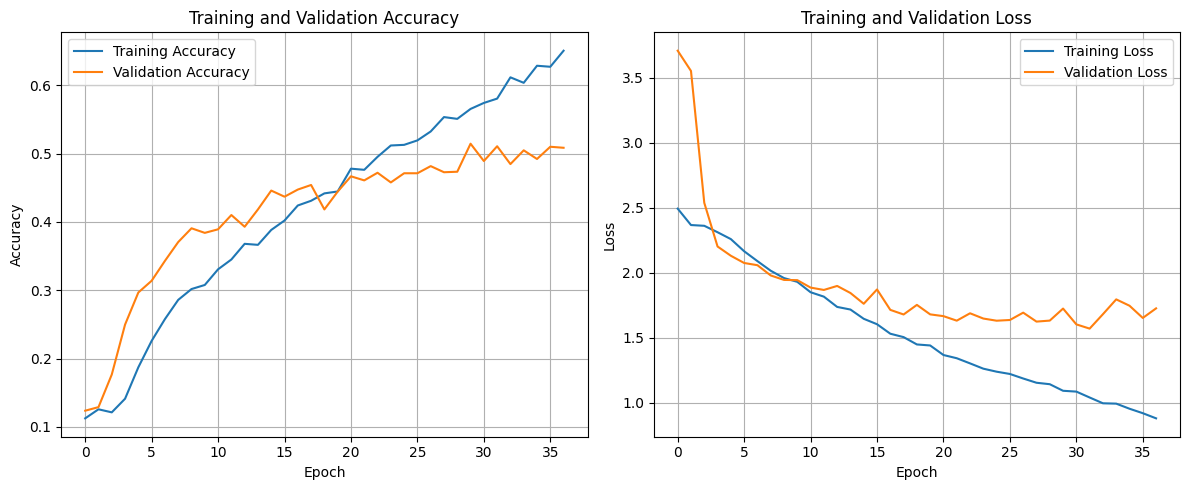

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
best_epoch = np.argmin(history.history['val_loss'])

val_loss = history.history['val_loss'][best_epoch]
val_acc = history.history['val_accuracy'][best_epoch]
train_loss = history.history['loss'][best_epoch]
train_acc = history.history['accuracy'][best_epoch]

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss:     {val_loss:.4f}")
print("-" * 30)
print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Training Loss:       {train_loss:.4f}")

Validation Accuracy: 0.5108
Validation Loss:     1.5700
------------------------------
Training Accuracy:   0.5805
Training Loss:       1.0404


Keep in mind that this is 11-class comparison.

Guessing probabilitity in 11-class comparison is 1/11≈9%

In [5]:
instrument_map = {
    'cel': 'Celesta',
    'cla': 'Clarinet',
    'flu': 'Flute',
    'gac': 'Acoustic Guitar',
    'gel': 'Electric Guitar',
    'org': 'Organ',
    'pia': 'Piano',
    'sax': 'Saxophone',
    'tru': 'Trumpet',
    'vio': 'Violin',
    'voi': 'Human Voice'
}

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

## THRESHOLD IS THE CONFIDENCE BAR WHICH DECIDES IF THERE IS AN X INSTRUMENT IN THE SAMPLE.
## WE HAVE 11 INSTRUMENTS SO RANDOM GUESSING WOULD BE AROUND 0.09.
## SO IF WE HAVE THRESHOLD OF 0.20 IT NEEDS TO HAVE ATLEAST 0.20 PROPABILITY TO BE FLAGGED THAT THE INSTRUMENT IS IN THE SAMPLE.

TARGET_CODE = 'sax'
PRED_THRESHOLD = 0.20 


target_idx = instrument_list.index(TARGET_CODE)

# per one .wav
def predict_on_test_file(file_path, model, idx):
    audio, sr = librosa.load(file_path, sr=22050) # sample rate, 22,050 * 3 = 66,150 samples per chunk
    chunk_size = 66150 # 3sec
    chunk_probs = []
    
    for i in range(0, len(audio) - chunk_size, chunk_size):
        chunk = audio[i : i + chunk_size]
        spec = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=128)
        #spec_db = librosa.power_to_db(spec, ref=np.max) # v1
        #spec_db = (spec_db - spec_db.min()) / (spec_db.max() - spec_db.min() + 1e-6) # v1
        spec_db = librosa.power_to_db(spec, ref=np.max) # v2
        spec_db = (spec_db + 80.0) / 80.0 # v2
        spec_db = np.clip(spec_db, 0, 1) # v2
        
        inp = spec_db[np.newaxis, ..., np.newaxis]
        pred = model.predict(inp, verbose=0)
        chunk_probs.append(pred[0][idx])
        
    # Return the highest confidence found across all 3s windows
    # If the instrument appears once, the whole file is flagged as a match (depending on the threshold of course)
    return np.max(chunk_probs) if chunk_probs else 0

y_true = []
y_pred_probs = []

test_files = [f for f in os.listdir(TEST_DIR) if f.endswith('.wav')]

print(f"Evaluating instrument: {instrument_map[TARGET_CODE]} (Index {target_idx})")

for f in test_files:
    file_path = os.path.join(TEST_DIR, f)
    txt_path = os.path.splitext(file_path)[0] + '.txt'
    
    is_present = 0
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as t:
            labels_in_file = [item.strip() for item in t.read().split()]
            if TARGET_CODE in labels_in_file:
                is_present = 1
    
    prob = predict_on_test_file(file_path, model, target_idx)
    y_true.append(is_present)
    y_pred_probs.append(prob)

y_pred_binary = [1 if p > PRED_THRESHOLD else 0 for p in y_pred_probs]
print("Done")

print(f"\nClassification Report for {instrument_map[TARGET_CODE]} ({PRED_THRESHOLD} Threshold):")
print(classification_report(y_true, y_pred_binary, target_names=[f'Not {instrument_map[TARGET_CODE]}', instrument_map[TARGET_CODE]]))

Evaluating instrument: Saxophone (Index 7)
Done

Classification Report for Saxophone (0.2 Threshold):
               precision    recall  f1-score   support

Not Saxophone       0.89      0.88      0.88       640
    Saxophone       0.55      0.58      0.56       167

     accuracy                           0.81       807
    macro avg       0.72      0.73      0.72       807
 weighted avg       0.82      0.81      0.82       807



RECALL = "Of all the X instruments in the test set, how many did the model actually find?"
PRECISION = "When the model says it's a X instrument, how often is it actually a X instrument?"
F1 SCORE = harmonic mean of prec and recall "The balance of the two"


**Earlier reports on different instruments and different thresholds:**

---

Classification Report for Saxophone (0.2 Threshold):
               precision    recall  f1-score   support

Not Saxophone       0.89      0.88      0.88       640
    Saxophone       0.55      0.58      0.56       167

     accuracy                           0.81       807
    macro avg       0.72      0.73      0.72       807
 weighted avg       0.82      0.81      0.82       807

---

Classification Report for Trumpet (0.2 Threshold):
              precision    recall  f1-score   support

 Not Trumpet       0.95      0.76      0.84       728
     Trumpet       0.22      0.62      0.32        79

    accuracy                           0.74       807
   macro avg       0.58      0.69      0.58       807
weighted avg       0.88      0.74      0.79       807

---

Classification Report for Acoustic Guitar (0.2 Threshold):
                     precision    recall  f1-score   support

Not Acoustic Guitar       0.93      0.89      0.91       662
    Acoustic Guitar       0.57      0.68      0.62       145

           accuracy                           0.85       807
          macro avg       0.75      0.78      0.76       807
       weighted avg       0.86      0.85      0.86       807

---

Classification Report for Violin (0.2 Threshold):
              precision    recall  f1-score   support

  Not Violin       0.95      0.88      0.91       756
      Violin       0.15      0.31      0.20        51

    accuracy                           0.84       807
   macro avg       0.55      0.60      0.56       807
weighted avg       0.90      0.84      0.87       807

---

Classification Report for Human Voice (0.2 Threshold):
                 precision    recall  f1-score   support

Not Human Voice       0.93      0.73      0.82       578
    Human Voice       0.56      0.87      0.68       229

       accuracy                           0.77       807
      macro avg       0.75      0.80      0.75       807
   weighted avg       0.83      0.77      0.78       807

--- v1 ---

Classification Report for Human Voice (0.20 Threshold) modelv1:
                 precision    recall  f1-score   support

Not Human Voice       0.91      0.63      0.74       578
    Human Voice       0.47      0.83      0.60       229

       accuracy                           0.69       807
      macro avg       0.69      0.73      0.67       807
   weighted avg       0.78      0.69      0.70       807

---

Classification Report (0.20 Threshold), piano modelv1:
              precision    recall  f1-score   support

   Not Piano       0.62      0.92      0.74       440
       Piano       0.77      0.34      0.47       367

    accuracy                           0.65       807
   macro avg       0.70      0.63      0.61       807
weighted avg       0.69      0.65      0.62       807

---

In [11]:
model.save("irmas_instrument_classifier_v2.keras")